# QPE Calibration Sweep on H2

This benchmark maps how QPE quality changes as you vary:

- ancilla count
- evolution time `t`
- Trotter steps
- shots

The point of the notebook is diagnostic calibration, not leaderboard chasing. In particular, repeated energies across many shot counts often indicate a phase-resolution or branch-selection plateau rather than sampling noise.

In [1]:
from __future__ import annotations

import time
from itertools import product

import matplotlib.pyplot as plt
import pandas as pd
import pennylane as qml

from common.hamiltonian import build_hamiltonian
from qpe import run_qpe
from qpe.core import bitstring_to_phase


In [2]:
molecule = "H2"

H, n_qubits, hf_state = build_hamiltonian(molecule)
exact_ground = float(qml.numpy.min(qml.numpy.linalg.eigvalsh(qml.matrix(H))))

ancillas_grid = [1, 2, 3, 4]
times_grid = [0.25, 0.5, 1.0, 2.0, 4.0]
trotter_grid = [1, 2, 4]
shots_grid = [None, 100, 500, 2000]

rows = []
for n_ancilla, t, trotter_steps, shots in product(
    ancillas_grid, times_grid, trotter_grid, shots_grid
):
    start = time.perf_counter()
    result = run_qpe(
        molecule=molecule,
        n_ancilla=n_ancilla,
        t=t,
        trotter_steps=trotter_steps,
        shots=shots,
        plot=False,
        force=False,
    )
    elapsed = time.perf_counter() - start

    phase_from_bitstring = bitstring_to_phase(result["best_bitstring"], msb_first=True)

    rows.append(
        {
            "n_ancilla": n_ancilla,
            "t": t,
            "trotter_steps": trotter_steps,
            "shots": result["shots"],
            "shot_mode": "analytic" if result["shots"] is None else "sampled",
            "estimated_energy": float(result["energy"]),
            "hf_energy": float(result["hf_energy"]),
            "exact_ground": exact_ground,
            "abs_error": abs(float(result["energy"]) - exact_ground),
            "best_bitstring": result["best_bitstring"],
            "phase": float(result["phase"]),
            "phase_from_bitstring": float(phase_from_bitstring),
            "phase_bin_width": 1.0 / (2 ** n_ancilla),
            "energy_minus_exact": float(result["energy"]) - exact_ground,
            "below_exact_ground": float(result["energy"]) < exact_ground,
            "elapsed_s": elapsed,
        }
    )

df = pd.DataFrame(rows).sort_values(["abs_error", "elapsed_s", "n_ancilla"])
df.head(15)


,n_ancilla,t,trotter_steps,shots,shot_mode,estimated_energy,hf_energy,exact_ground,abs_error,best_bitstring,phase,phase_from_bitstring,phase_bin_width,energy_minus_exact,below_exact_ground,elapsed_s
167,3,2.0,4,2000.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,011,0.3750,0.3750,0.1250,-0.040827,True,0.034048
214,4,1.0,4,500.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,0011,0.1875,0.1875,0.0625,-0.040827,True,0.034113
163,3,2.0,2,2000.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,011,0.3750,0.3750,0.1250,-0.040827,True,0.034117
161,3,2.0,2,100.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,011,0.3750,0.3750,0.1250,-0.040827,True,0.034164
165,3,2.0,4,100.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,011,0.3750,0.3750,0.1250,-0.040827,True,0.034270
162,3,2.0,2,500.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,011,0.3750,0.3750,0.1250,-0.040827,True,0.034357
158,3,2.0,1,500.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,011,0.3750,0.3750,0.1250,-0.040827,True,0.034413
157,3,2.0,1,100.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,011,0.3750,0.3750,0.1250,-0.040827,True,0.035040
213,4,1.0,4,100.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,0011,0.1875,0.1875,0.0625,-0.040827,True,0.035306
215,4,1.0,4,2000.0,sampled,-1.178097,-1.116684,-1.13727,0.040827,0011,0.1875,0.1875,0.0625,-0.040827,True,0.035584


In [3]:
summary = (
    df.groupby(["n_ancilla", "t", "trotter_steps"], as_index=False)
    .agg(
        best_abs_error=("abs_error", "min"),
        mean_abs_error=("abs_error", "mean"),
        n_unique_energies=("estimated_energy", "nunique"),
        n_unique_bitstrings=("best_bitstring", "nunique"),
        any_below_exact=("below_exact_ground", "any"),
    )
    .sort_values(["best_abs_error", "n_ancilla", "t"])
)
summary.head(20)


,n_ancilla,t,trotter_steps,best_abs_error,mean_abs_error,n_unique_energies,n_unique_bitstrings,any_below_exact
27,2,4.0,1,0.040827,0.040827,1,1,True
28,2,4.0,2,0.040827,0.040827,1,1,True
29,2,4.0,4,0.040827,0.040827,1,1,True
39,3,2.0,1,0.040827,0.040827,1,1,True
40,3,2.0,2,0.040827,0.040827,1,1,True
41,3,2.0,4,0.040827,0.040827,1,1,True
42,3,4.0,1,0.040827,0.040827,1,1,True
51,4,1.0,1,0.040827,0.040827,1,1,True
52,4,1.0,2,0.040827,0.040827,1,1,True
53,4,1.0,4,0.040827,0.040827,1,1,True


In [4]:
plateaus = (
    df.groupby(["n_ancilla", "t", "trotter_steps"], as_index=False)
    .filter(lambda g: g["estimated_energy"].nunique() == 1 and len(g) > 1)
    .sort_values(["n_ancilla", "t", "trotter_steps", "shots"], na_position="first")
)
plateaus[[
    "n_ancilla",
    "t",
    "trotter_steps",
    "shots",
    "shot_mode",
    "estimated_energy",
    "abs_error",
    "best_bitstring",
    "phase",
    "phase_from_bitstring",
    "phase_bin_width",
]].head(20)


,n_ancilla,t,trotter_steps,shots,shot_mode,estimated_energy,abs_error,best_bitstring,phase,phase_from_bitstring,phase_bin_width
0,1,0.25,1,NaN,analytic,0.0,1.13727,0,0.0,0.0,0.5
1,1,0.25,1,100.0,sampled,0.0,1.13727,0,0.0,0.0,0.5
2,1,0.25,1,500.0,sampled,0.0,1.13727,0,0.0,0.0,0.5
3,1,0.25,1,2000.0,sampled,0.0,1.13727,0,0.0,0.0,0.5
4,1,0.25,2,NaN,analytic,0.0,1.13727,0,0.0,0.0,0.5
5,1,0.25,2,100.0,sampled,0.0,1.13727,0,0.0,0.0,0.5
6,1,0.25,2,500.0,sampled,0.0,1.13727,0,0.0,0.0,0.5
7,1,0.25,2,2000.0,sampled,0.0,1.13727,0,0.0,0.0,0.5
8,1,0.25,4,NaN,analytic,0.0,1.13727,0,0.0,0.0,0.5
9,1,0.25,4,100.0,sampled,0.0,1.13727,0,0.0,0.0,0.5


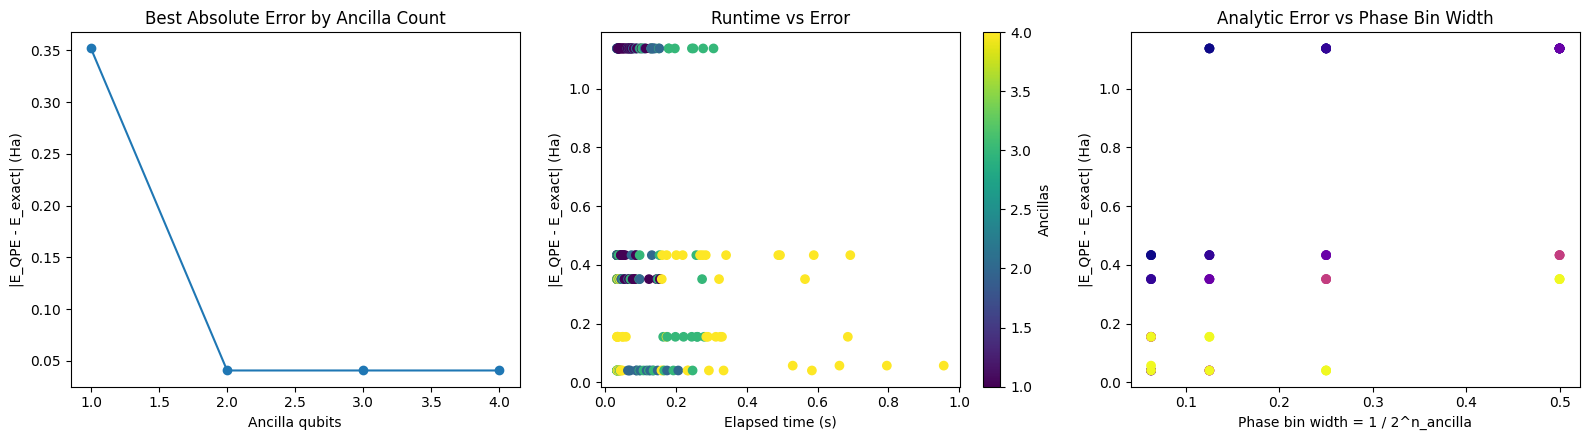

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

best_by_ancilla = (
    df.groupby("n_ancilla", as_index=False)["abs_error"]
    .min()
    .sort_values("n_ancilla")
)
axes[0].plot(best_by_ancilla["n_ancilla"], best_by_ancilla["abs_error"], marker="o")
axes[0].set_title("Best Absolute Error by Ancilla Count")
axes[0].set_xlabel("Ancilla qubits")
axes[0].set_ylabel("|E_QPE - E_exact| (Ha)")

scatter = axes[1].scatter(
    df["elapsed_s"],
    df["abs_error"],
    c=df["n_ancilla"],
    cmap="viridis",
)
axes[1].set_title("Runtime vs Error")
axes[1].set_xlabel("Elapsed time (s)")
axes[1].set_ylabel("|E_QPE - E_exact| (Ha)")
fig.colorbar(scatter, ax=axes[1], label="Ancillas")

analytic = df[df["shot_mode"] == "analytic"].sort_values(["t", "n_ancilla", "trotter_steps"])
axes[2].scatter(
    analytic["phase_bin_width"],
    analytic["abs_error"],
    c=analytic["t"],
    cmap="plasma",
)
axes[2].set_title("Analytic Error vs Phase Bin Width")
axes[2].set_xlabel("Phase bin width = 1 / 2^n_ancilla")
axes[2].set_ylabel("|E_QPE - E_exact| (Ha)")

plt.tight_layout()
plt.show()


## Interpretation Notes

- If many sampled runs with different `shots` collapse to the same `best_bitstring` and `estimated_energy`, the dominant limit is usually phase resolution or branch selection, not sampling noise.
- Energies below the exact ground state should be treated as a diagnostic warning. In this notebook they usually signal Trotter / branch / discretization bias rather than a genuinely better estimate.
- The analytic `shots=None` rows are useful as a baseline: if sampled rows match them closely, more shots will not materially improve the estimate for that `(n_ancilla, t, trotter_steps)` regime.
- For larger systems, keep the same diagnostics but reduce the sweep grid before scaling the chemistry.